In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
from util import calculate_pass_at_k

In [3]:
# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

In [4]:
paths = [
    '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__kl-cov/val_jsonl/0_rollouts.jsonl',
    '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__kl-cov/val_jsonl/30_rollouts.jsonl',
    '/ptmp/rfechner/out/exp17_rollouts/seed2__qwen2.5_7b__kl-cov/val_jsonl/30_rollouts.jsonl',
    '/ptmp/rfechner/out/exp17_rollouts/seed3__qwen2.5_7b__kl-cov/val_jsonl/30_rollouts.jsonl'
]
names = ['base', 'seed1', 'seed2', 'seed3']
dfs = {}
for name, path in zip(names, paths):
    with open(path, 'r') as file:
        df = pd.read_json(file, lines=True)
        dfs[name] = calculate_pass_at_k(df)

In [5]:
dfs['base']['aime25']

array([[0.0390625 , 0.07674632, 0.14815043, 0.27624623, 0.48180953,
        0.74362438, 0.94698407, 0.99918642, 1.        ],
       [0.00390625, 0.0078125 , 0.015625  , 0.03125   , 0.0625    ,
        0.125     , 0.25      , 0.5       , 1.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.0078125 , 0.01559436, 0.03106618, 0.06164216, 0.12132353,
        0.23480392, 0.43823529, 0.75098039, 1.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.16796875, 0.30827206, 0.52303904, 0.77544827, 0.95222356,
        0.99819073, 0.9999989 , 1.        , 1.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],


In [6]:
import numpy as np
p256_values = {}
for k, vs in dfs.items():
    ps = []
    for dataset, vvs in vs.items():
        ps.append(vvs[:, -1])
    p256_values[k] = np.concat(ps, axis=0).astype(bool)

In [7]:
expansion, shrinkage = {}, {}
pass256_base = p256_values['base']
for name in names[1:]:
    expansion[name] = ~pass256_base & p256_values[name]
    shrinkage[name] = pass256_base & ~p256_values[name]

# --- prune uninteresting indices ---
# stack: shape (num_methods, num_questions)
exp_stack = np.stack(list(expansion.values()), axis=0)
shr_stack = np.stack(list(shrinkage.values()), axis=0)

# expansion: drop questions never solved by any method
exp_keep_mask = np.any(exp_stack, axis=0)

# shrinkage: drop questions always solved by all methods
# (i.e., no shrinkage occurs for any method)
shr_keep_mask = np.any(shr_stack, axis=0)

# apply masks
for k in expansion:
    expansion[k] = expansion[k][exp_keep_mask]

for k in shrinkage:
    shrinkage[k] = shrinkage[k][shr_keep_mask]

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import from_indicators, plot

def plot_upset(expansion, shrinkage):
    """
    Erstellt UpSet-Plots mit spezifischen Farben und Sortierung.
    Expansion: Light Green
    Shrinkage: Light Red
    """
    datasets = [
        (expansion, "Expansion, Qwen2.5-7B and KL-Cov, 3 Seeds", "#50B428", "expansion"), # Light Green
        (shrinkage, "Shrinkage, Qwen2.5-7B and KL-Cov, 3 Seeds", "#E3615F", "shrinkage")   # Light Red
    ]

    for data, title, color, handle in datasets:
        if not data:
            continue
            
        df = pd.DataFrame(data)
        upset_data = from_indicators(indicators=df.columns, data=df)
        fig = plt.figure(figsize=(5, 4))
        
        # sort_by='cardinality' sortiert nach der Größe der Schnittmengen
        plot(upset_data, 
             fig=fig, 
             facecolor=color, 
             sort_by='cardinality', 
             show_counts=True)
        
        fig.suptitle(title, fontsize=14)
        plt.show()
        
    
        # Save as vector PDF
        keys = set(expansion.keys())
        keys = [k.replace('@', '_at_') for k in keys]
        outfile = f"UpSet__{handle}_seeds.pdf"
        fig.savefig(os.path.join('/u/rfechner/verl/plots/outcome_based2', outfile), format="pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

/u/rfechner/conda-envs/notebooks/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/u/rfechner/conda-envs/notebooks/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

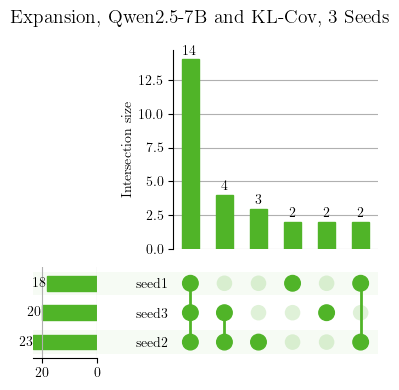

/u/rfechner/conda-envs/notebooks/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/u/rfechner/conda-envs/notebooks/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

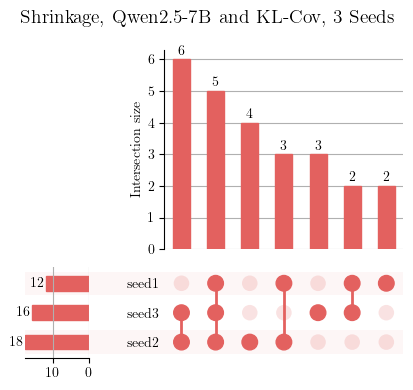

In [9]:
plot_upset(expansion, shrinkage)